# Dense vs MoE — training curves

Compare `train_loss` (logged every 10 steps) and `val_loss` (steps 100, 200) from toy GLM runs.

Logs: `david/demo/runs/{dense,moe}.jsonl`

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

RUNS = Path("runs")  # relative to this notebook (david/demo/)


def load_run(path: Path) -> pd.DataFrame:
    rows = [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
    return pd.DataFrame(rows)


dense = load_run(RUNS / "dense.jsonl")
moe = load_run(RUNS / "moe.jsonl")

def split_train_val(df: pd.DataFrame):
    train = df.dropna(subset=["train_loss"])[["step", "train_loss"]].sort_values("step")
    val = df.dropna(subset=["val_loss"])[["step", "val_loss"]].sort_values("step")
    return train, val

dense_train, dense_val = split_train_val(dense)
moe_train, moe_val = split_train_val(moe)

print(f"dense  train={len(dense_train)}  val={len(dense_val)}")
print(f"moe    train={len(moe_train)}  val={len(moe_val)}")
dense_train.head()

dense  train=20  val=2
moe    train=20  val=2


,step,train_loss
0,10,8.007113
1,20,7.233915
2,30,6.666413
3,40,6.237604
4,50,5.959194


saved runs/dense_vs_moe_loss.pdf and runs/dense_vs_moe_loss.png


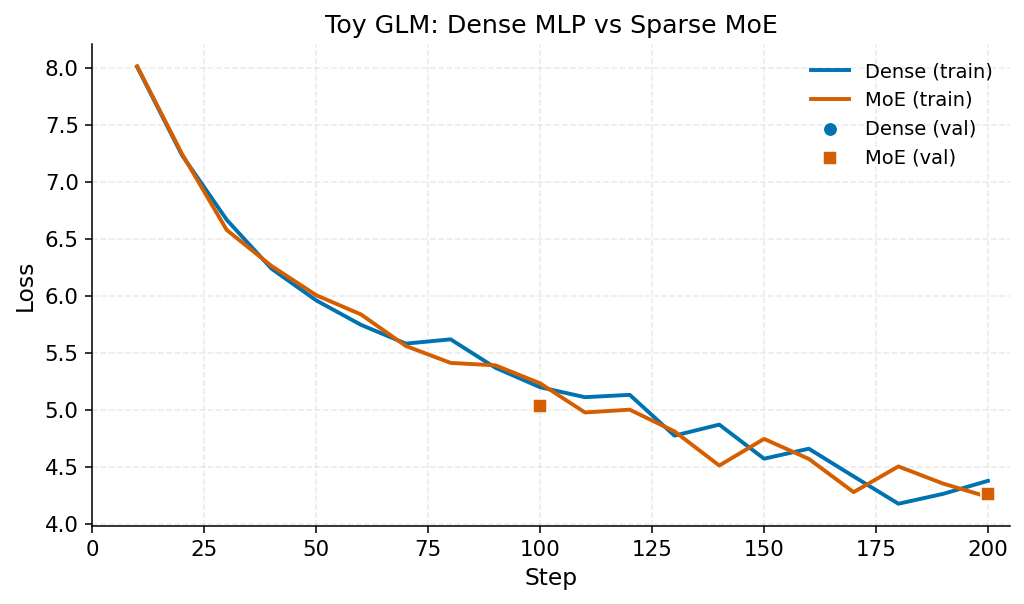

In [2]:
# Paper-style defaults: muted palette, light grid, no chartjunk
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# Colorblind-friendly (Okabe–Ito)
C_DENSE = "#0072B2"  # blue
C_MOE = "#D55E00"    # vermillion

fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)

# Train curves
ax.plot(
    dense_train["step"], dense_train["train_loss"],
    color=C_DENSE, lw=2.0, label="Dense (train)",
)
ax.plot(
    moe_train["step"], moe_train["train_loss"],
    color=C_MOE, lw=2.0, label="MoE (train)",
)

# Val markers (sparse) — same hue, distinct marker
ax.scatter(
    dense_val["step"], dense_val["val_loss"],
    color=C_DENSE, s=55, marker="o", zorder=5,
    edgecolors="white", linewidths=0.8, label="Dense (val)",
)
ax.scatter(
    moe_val["step"], moe_val["val_loss"],
    color=C_MOE, s=55, marker="s", zorder=5,
    edgecolors="white", linewidths=0.8, label="MoE (val)",
)

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Toy GLM: Dense MLP vs Sparse MoE")
ax.legend(frameon=False, loc="upper right")
ax.set_xlim(0, max(dense_train["step"].max(), moe_train["step"].max()) + 5)

out = RUNS / "dense_vs_moe_loss.pdf"
fig.savefig(out, bbox_inches="tight")
fig.savefig(out.with_suffix(".png"), bbox_inches="tight")
print(f"saved {out} and {out.with_suffix('.png')}")
plt.show()

In [3]:
# Final checkpoint summary (step 200)
def final_metrics(name, train, val):
    return {
        "run": name,
        "final_train_loss": float(train.loc[train["step"].idxmax(), "train_loss"]),
        "final_val_loss": float(val.loc[val["step"].idxmax(), "val_loss"]),
        "best_val_loss": float(val["val_loss"].min()),
        "best_val_step": int(val.loc[val["val_loss"].idxmin(), "step"]),
    }

summary = pd.DataFrame([
    final_metrics("dense", dense_train, dense_val),
    final_metrics("moe", moe_train, moe_val),
]).set_index("run")

summary.round(4)

,final_train_loss,final_val_loss,best_val_loss,best_val_step
run,,,,
dense,4.3767,4.2677,4.2677,200
moe,4.2359,4.2652,4.2652,200
